In [1]:
# Upload CSV file if running directly in Colab
from google.colab import files
uploaded = files.upload()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Saving pimpri_chinchwad_rainfall_2015_2024.csv to pimpri_chinchwad_rainfall_2015_2024.csv


In [2]:
# Load dataset
df = pd.read_csv('pimpri_chinchwad_rainfall_2015_2024.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Create cyclical features for seasonality (sine and cosine transforms)
df['DayOfYear'] = df['Date'].dt.dayofyear
df['Sin_Month'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Cos_Month'] = np.cos(2 * np.pi * df['Month'] / 12)

# Create lag and rolling features
df['Rain_Lag1'] = df['Rainfall_mm'].shift(1).fillna(0)
df['Rain_Rolling7'] = df['Rainfall_mm'].rolling(window=7, min_periods=1).mean()

print(df.head())

        Date  Year  Month  Day   Weekday  Rainfall_mm  Temperature_C  \
0 2015-01-01  2015      1    1  Thursday          0.0           20.0   
1 2015-01-02  2015      1    2    Friday          0.0           17.9   
2 2015-01-03  2015      1    3  Saturday          0.0           20.2   
3 2015-01-04  2015      1    4    Sunday          0.0           23.6   
4 2015-01-05  2015      1    5    Monday          0.0           25.6   

   Humidity_pct  DayOfYear  Sin_Month  Cos_Month  Rain_Lag1  Rain_Rolling7  
0          40.4          1        0.5   0.866025        0.0            0.0  
1          42.2          2        0.5   0.866025        0.0            0.0  
2          41.3          3        0.5   0.866025        0.0            0.0  
3          43.9          4        0.5   0.866025        0.0            0.0  
4          47.0          5        0.5   0.866025        0.0            0.0  


In [3]:
# Define feature set and target
features = ['Temperature_C', 'Humidity_pct', 'Sin_Month', 'Cos_Month', 'Rain_Lag1', 'Rain_Rolling7']
target = 'Rainfall_mm'

X = df[features]
y = df[target]

# Chronological split: 2015-2022 for Training, 2023-2024 for Testing
train_idx = df['Year'] < 2023
test_idx = df['Year'] >= 2023

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"Training Samples: {len(X_train)} | Testing Samples: {len(X_test)}")

Training Samples: 2922 | Testing Samples: 731


In [4]:
# Define feature set and target
features = ['Temperature_C', 'Humidity_pct', 'Sin_Month', 'Cos_Month', 'Rain_Lag1', 'Rain_Rolling7']
target = 'Rainfall_mm'

X = df[features]
y = df[target]

# Chronological split: 2015-2022 for Training, 2023-2024 for Testing
train_idx = df['Year'] < 2023
test_idx = df['Year'] >= 2023

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"Training Samples: {len(X_train)} | Testing Samples: {len(X_test)}")

Training Samples: 2922 | Testing Samples: 731


In [5]:
# Initialize and train Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions (clip at 0 to avoid negative rainfall values)
y_pred_train = np.clip(model.predict(X_train), 0, None)
y_pred_test = np.clip(model.predict(X_test), 0, None)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)

print(f"Test MAE:  {mae:.3f} mm")
print(f"Test RMSE: {rmse:.3f} mm")
print(f"Test R²:   {r2:.3f}")

Test MAE:  1.454 mm
Test RMSE: 3.281 mm
Test R²:   0.432


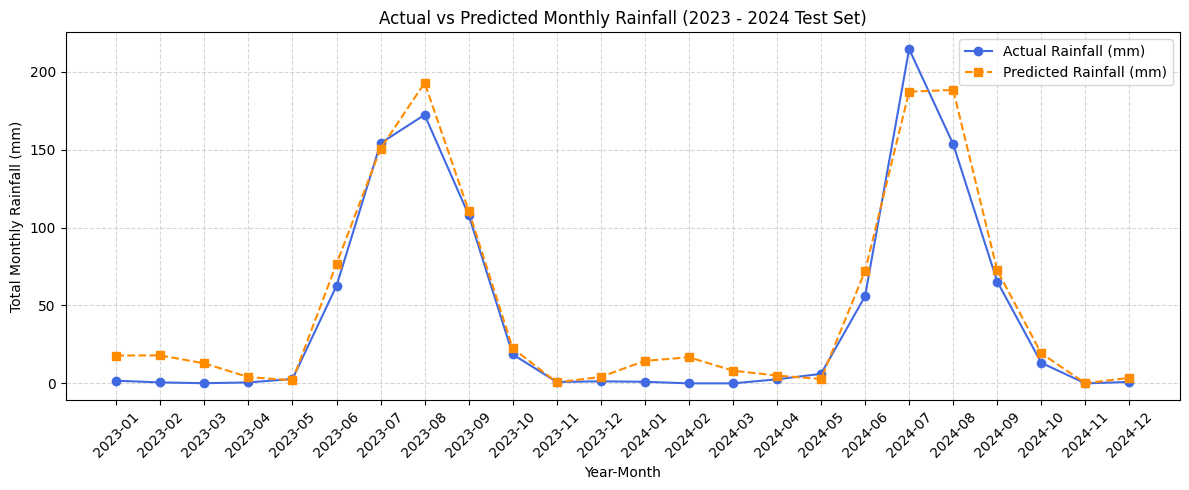

In [6]:
# Compare actual vs predicted monthly totals for test set
test_df = df[test_idx].copy()
test_df['Predicted_Rainfall_mm'] = y_pred_test

monthly_summary = test_df.groupby(['Year', 'Month'])[['Rainfall_mm', 'Predicted_Rainfall_mm']].sum().reset_index()
monthly_summary['Period'] = monthly_summary['Year'].astype(str) + '-' + monthly_summary['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(12, 5))
plt.plot(monthly_summary['Period'], monthly_summary['Rainfall_mm'], label='Actual Rainfall (mm)', marker='o', color='royalblue')
plt.plot(monthly_summary['Period'], monthly_summary['Predicted_Rainfall_mm'], label='Predicted Rainfall (mm)', marker='s', color='darkorange', linestyle='--')
plt.xticks(rotation=45)
plt.xlabel('Year-Month')
plt.ylabel('Total Monthly Rainfall (mm)')
plt.title('Actual vs Predicted Monthly Rainfall (2023 - 2024 Test Set)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [7]:
# Integrate predicted rainfall with catchment parameters for harvesting
CATCHMENT_AREA_M2 = 9522.35
RUNOFF_COEFFICIENT = 0.85

test_df['Harvested_Liters_Pred'] = test_df['Predicted_Rainfall_mm'] * CATCHMENT_AREA_M2 * RUNOFF_COEFFICIENT

annual_harvest_pred = test_df.groupby('Year')['Harvested_Liters_Pred'].sum() / 1e6
print("\nPredicted Annual Rainwater Harvesting Yield (Megaliters):")
print(annual_harvest_pred)


Predicted Annual Rainwater Harvesting Yield (Megaliters):
Year
2023    4.960757
2024    4.776799
Name: Harvested_Liters_Pred, dtype: float64
